# Report Statistics

In [ ]:
## Methodology - 3.1

In [7]:
import ast
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/takshgirdhar/Desktop/DATA 448 - Directed Studies/Sentiment-Analysis-Research-Project/data/fabsa/fabsa_dataset.csv")

print(df.head())
print(df.columns)
print(f"Total reviews: {len(df)}")

          id                                               text  \
0  301988849                Literally only place I get my shoes   
1  301988545                              Will not let me login   
2  576785371  I've already reviewed it, so please let me sig...   
3  301983983                      Easy to use and price is good   
4  301988330  I find this app easy to use and with an extens...   

                                              labels  org_index  \
0           ['company-brand.general-satisfaction.1']        727   
1           ['account-management.account-access.-1']        727   
2            ['account-management.account-access.0']       5827   
3  ['purchase-booking-experience.ease-of-use.1', ...        549   
4  ['purchase-booking-experience.ease-of-use.1', ...        727   

         industry  data_source  
0         Fashion  Google Play  
1         Fashion  Google Play  
2      Consulting  Apple Store  
3  Travel Booking  Google Play  
4         Fashion  Google Pla

In [9]:
import re
import ast

ASPECTS = [
    "account-management.account-access",
    "company-brand.competitor",
    "company-brand.general-satisfaction",
    "company-brand.reviews",
    "logistics-rides.speed",
    "online-experience.app-website",
    "purchase-booking-experience.ease-of-use",
    "staff-support.attitude-of-staff",
    "staff-support.phone",
    "staff-support.email",
    "value.discounts-promotions",
    "value.price-value-for-money",
]
SENTIMENT_MAP = {
    "1": "positive",
    "0": "neutral",
    "-1": "negative"
}
SENTIMENTS = ["positive", "negative", "neutral"]


def parse_label_string(raw):
    """Parse labels stored as: ['aspect.sentimentid', ...]."""
    if pd.isna(raw):
        return []
    s = str(raw).strip()
    tokens = re.split(r"[;,\s]+", s)
    return [t for t in tokens if t]


def split_aspect_sent(token):
    """
    Split: 'online-experience.app-website.-1'
        → aspect='online-experience.app-website'
        → sentiment='negative'
    """
    t = str(token).strip().strip("'").strip('"')
    match = re.match(r"(.+)\.(-?1|0)$", t)
    if match:
        aspect = match.group(1)
        sent_id = match.group(2)
        sentiment = SENTIMENT_MAP.get(sent_id, "unknown")
        return aspect, sentiment

    return t, "unknown"

rows = []
for _, row in df.iterrows():
    tokens = parse_label_string(row["labels"])
    for tok in tokens:
        aspect, sent = split_aspect_sent(tok)
        rows.append(
            {
                "id": row["id"],
                "text": row["text"],
                "industry": row["industry"],
                "data_source": row["data_source"],
                "aspect": aspect,
                "sentiment": sent,
            }
        )

df_labels = pd.DataFrame(rows)
df_labels = df_labels[df_labels["sentiment"].isin(SENTIMENTS)]  # drop unknown if any

print(df_labels.head())
print(f"Total aspect–sentiment instances: {len(df_labels)}")

           id                                               text  \
3   301983983                      Easy to use and price is good   
5   301988330  I find this app easy to use and with an extens...   
8   301984447  Agoda's oath likes to be clear so far 2 times ...   
9   301984447  Agoda's oath likes to be clear so far 2 times ...   
11  301981664  Great for using abroad. I use it in Europe and...   

          industry  data_source                                     aspect  \
3   Travel Booking  Google Play  ['purchase-booking-experience.ease-of-use   
5          Fashion  Google Play  ['purchase-booking-experience.ease-of-use   
8   Travel Booking  Google Play            ['online-experience.app-website   
9   Travel Booking  Google Play    purchase-booking-experience.ease-of-use   
11         Banking  Google Play       ['company-brand.general-satisfaction   

   sentiment  
3   positive  
5   positive  
8   negative  
9   negative  
11  positive  
Total aspect–sentiment instances

### Distribution of Aspects

aspect
['purchase-booking-experience.ease-of-use    1698
['online-experience.app-website              1308
['staff-support.attitude-of-staff             994
online-experience.app-website                 744
['company-brand.general-satisfaction          516
purchase-booking-experience.ease-of-use       477
company-brand.general-satisfaction            397
value.price-value-for-money                   366
['value.discounts-promotions                  282
['account-management.account-access           245
['company-brand.reviews                       151
['staff-support.phone                         132
['value.price-value-for-money                 132
logistics-rides.speed                          98
account-management.account-access              83
staff-support.phone                            82
staff-support.attitude-of-staff                76
['logistics-rides.speed                        69
company-brand.competitor                       67
['company-brand.competitor                 

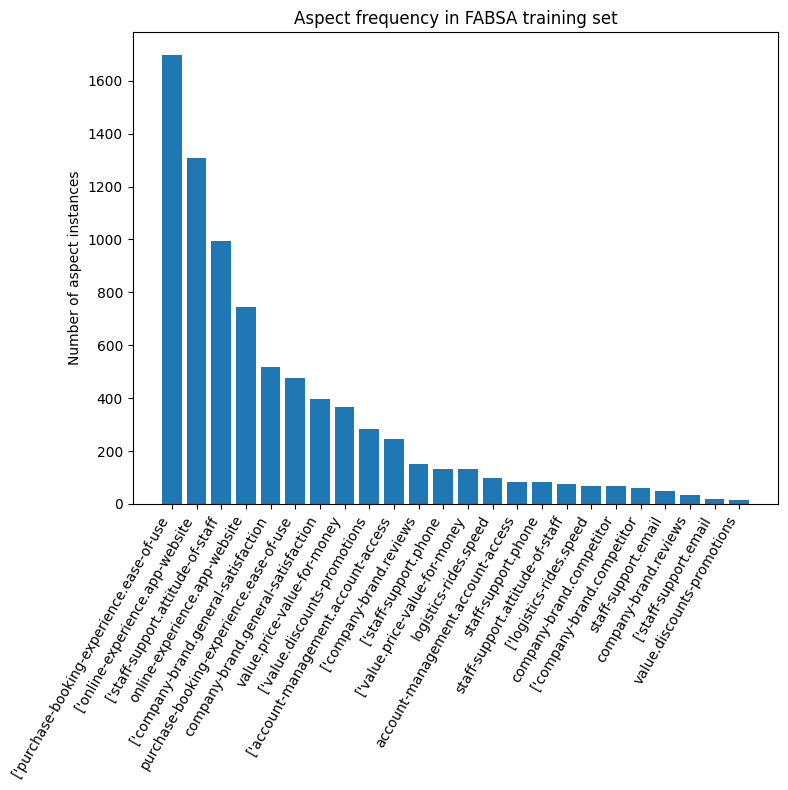

In [11]:

aspect_counts = df_labels["aspect"].value_counts().sort_values(ascending=False)

print(aspect_counts)

plt.figure(figsize=(8,8))
plt.bar(aspect_counts.index, aspect_counts.values)
plt.xticks(rotation=60, ha="right")
plt.ylabel("Number of aspect instances")
plt.title("Aspect frequency in FABSA training set")
plt.tight_layout()
plt.show()

sentiment
positive    5308
negative    2740
neutral       46
Name: count, dtype: int64


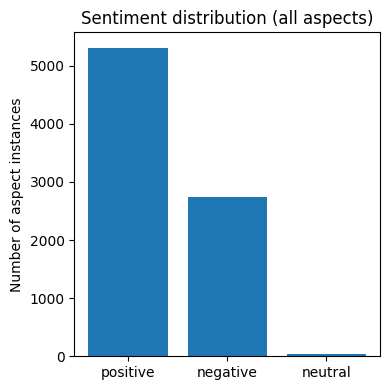

In [12]:

sent_counts = df_labels["sentiment"].value_counts().reindex(SENTIMENTS)

print(sent_counts)

plt.figure(figsize=(4,4))
plt.bar(sent_counts.index, sent_counts.values)
plt.ylabel("Number of aspect instances")
plt.title("Sentiment distribution (all aspects)")
plt.tight_layout()
plt.show()

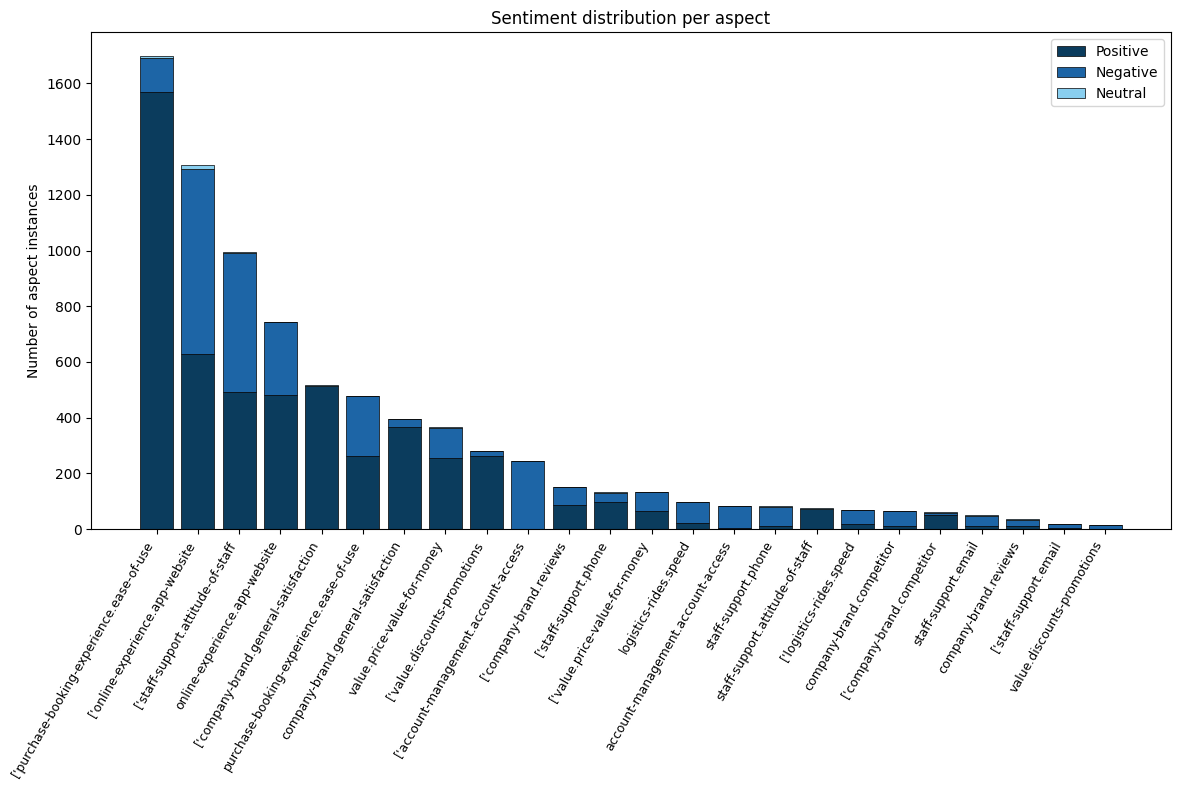

In [ ]:
color_map = {
    "positive": "#0B3C5D",   # dark navy blue
    "negative": "#1D65A6",   # medium blue
    "neutral":  "#89CFF0"    # light blue
}

aspect_sent_counts = (
    df_labels
    .groupby(["aspect", "sentiment"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=aspect_counts.index, columns=SENTIMENTS)
)

plt.figure(figsize=(12,8))
bottom = np.zeros(len(aspect_sent_counts))
x = np.arange(len(aspect_sent_counts))

for s in SENTIMENTS:
    vals = aspect_sent_counts[s].values
    plt.bar(
        x,
        vals,
        bottom=bottom,
        label=s.capitalize(),
        color=color_map[s],
        edgecolor="black",    
        linewidth=0.5
    )
    bottom += vals

plt.xticks(x, aspect_sent_counts.index, rotation=60, ha="right", fontsize=9)
plt.ylabel("Number of aspect instances")
plt.title("Sentiment distribution per aspect")
plt.legend()
plt.tight_layout()
plt.show()